# Combining Sample and Control Files (qc, blank, env blank) for later removing contamination

In [1]:
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.spatial.distance import pdist
from difflib import get_close_matches
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from itertools import combinations
 

# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]
# Replace these with  actual QC, env, blank file paths beacuse we want to remove the contamination and get the actual peaks for samples
qc_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")
all_files = (
    [(f,"sample") for f in sample_files] +
    [(f, "qc") for f in qc_files] +
    [(f, "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)
rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
combined = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV to use it later
combined.to_csv(output_path, index=False)
print(f"Combined dataset saved to: {output_path}")
combined.head()

Combined dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filtering True Sample Compounds

In [2]:
# Exclude compounds found in blanks/QCs/env
exclude = combined.loc[
    combined['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only actual sample compounds, removing excluded ones
real = combined.loc[
    (combined['FileType'] == 'sample') &
    (~combined['Compound Name'].isin(exclude))
].copy()

# Print filtered data shape and show head
print("Filtered sample compounds:", real.shape)
real.head()

Filtered sample compounds: (2498, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Checking the presence of known potato aroma compounds

In [3]:
# Here's our established list of potato aroma volatiles – these are the specific compounds
# we're looking for, based on previous knowledge and other research.
potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-",
    "Heptanal", "Octanal", "Decanal",
    "2-Heptanone", "2-Nonanone", "3-Heptanone",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "2-Ethyl-3,5-dimethylpyrazine", "2-Isobutyl-3-methoxypyrazine",
    "1-Heptanol", "1-Nonanol",
    "Methanethiol", "Dimethyl tetrasulfide", "Carbon disulfide",
    "Acetic acid", "Butanoic acid", "Hexanoic acid"
]

# To make sure we can match names even if they have slight differences (like spaces or hyphens),
# we're creating a 'normalize' function. This converts names to lowercase and removes punctuation.
def normalize(name):
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')
# We apply this normalization to our reference aroma list, creating a lookup dictionary.
ref_norm = { normalize(x): x for x in potato_aromas }

# Then, we create a normalized version of each compound name in our 'real' dataset.
real['norm_name'] = real['Compound Name'].apply(normalize)
# We start by checking for exact matches: is the normalized compound name in our normalized aroma list?
real['is_aroma'] = real['norm_name'].isin(ref_norm)

# Sometimes compound names are slightly different but still refer to the same thing.
# This 'fuzzy_match' function uses 'get_close_matches' to find names that are very similar
# to our reference aromas, even if they're not an exact match.
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

# We're interested in the compounds that *weren't* an exact match in the first step.
mask = ~real['is_aroma']
# For these non-exact matches, we try to find a close match in our reference aroma list.
fuzzy_hits = real.loc[mask, 'norm_name'].map(lambda n: fuzzy_match(n, list(ref_norm)))

# If a fuzzy match was found (meaning 'fuzzy_hits' is not empty for that row),
# we mark that compound as an aroma and update its 'Compound Name' to the official reference name.
real.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
real.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = fuzzy_hits.map(ref_norm)

# Now, we filter our data to keep *only* the compounds that we've identified as potato aromas.
aroma_samples = real[real['is_aroma']].copy()
print(aroma_samples)
# Finally, we want to see which unique aroma compounds are present in each sample.
# We group by 'FileName' and collect all the unique 'Compound Name' values for each.
aroma_per_sample = (
    aroma_samples
    .groupby('FileName')['Compound Name']
    .unique()
    .reset_index(name='Aroma Compounds')
)
# Display the first few rows of our aroma profiles per sample.
aroma_per_sample.head()

      Component RT                  Compound Name  Match Factor  Best Hit  \
0         2.185667        2-Propanone, 1-methoxy-     91.035716      True   
1         2.899483             Butanal, 3-methyl-     95.554383      True   
2         3.317483                       Pentanal     91.360114      True   
4         5.282067                        Hexanal     93.609765      True   
5         5.883333  Cyclotrisiloxane, hexamethyl-     97.889204      True   
...            ...                            ...           ...       ...   
2472     12.095450                        Nonanal     96.145875      True   
2479      5.886867  Cyclotrisiloxane, hexamethyl-     96.443038      True   
2480      9.334584                   Benzaldehyde     96.443432      True   
2484     12.092500                        Nonanal     96.679990      True   
2487     13.722683                        Decanal     92.708188      True   

         Formula FileType       FileName                   norm_name  is_ar

,FileName,Aroma Compounds
0,sample_1.csv,"[Butanal, 3-methyl-, Cyclotrisiloxane, hexamet..."
1,sample_10.csv,"[2-Propanone, 1-methoxy-, Butanal, 3-methyl-, ..."
2,sample_11.csv,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."
3,sample_12.csv,"[Butanal, 3-methyl-, Hexanal, Cyclotrisiloxane..."
4,sample_13.csv,"[Cyclotrisiloxane, hexamethyl-, Benzaldehyde, ..."


# Map variety on samples

In [4]:

# Load master table
master = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
)

# Work with aroma_samples
aroma_samples = aroma_samples.copy()
aroma_samples['SampleNumber'] = aroma_samples['FileName'].str.extract(r'(\d+)').astype(int)

# Filter valid rows from master
valid_master = master[
    ~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])
].copy()
valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B')[0].astype(int)
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge to map varieties
aroma_mapped = pd.merge(aroma_samples, sample_to_variety, on='SampleNumber', how='left')

# Keep only needed columns and rename for clarity
aroma_mapped_clean = aroma_mapped[['SampleNumber', 'Variety', 'FileName', 'Compound Name', 'Component RT']].copy()
aroma_mapped_clean.rename(columns={
    'Compound Name': 'Aroma Compound',
    'Component RT': 'Retention Time (min)'
}, inplace=True)

# Sort for readability
aroma_mapped_clean.sort_values(['Variety', 'SampleNumber', 'Retention Time (min)'], inplace=True)

# Save to CSV
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\aroma_mapped_separate_columns.csv"
aroma_mapped_clean.to_csv(output_path, index=False)
print(f"Final dataset saved to: {output_path}")
aroma_mapped_clean.head()


Final dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\aroma_mapped_separate_columns.csv


,SampleNumber,Variety,FileName,Aroma Compound,Retention Time (min)
351,1,ADORA,sample_1.csv,"Butanal, 3-methyl-",2.893083
352,1,ADORA,sample_1.csv,"Cyclotrisiloxane, hexamethyl-",5.902667
353,1,ADORA,sample_1.csv,Benzaldehyde,9.337945
354,1,ADORA,sample_1.csv,"Cyclotrisiloxane, hexamethyl-",10.117983
355,1,ADORA,sample_1.csv,Octanal,10.220883


# Building Variety - Compound matrix we used for some later analysis

In [5]:
# Explode for long format
exploded = aroma_mapped_clean.explode('Aroma Compound').dropna(subset=['Aroma Compound', 'Variety'])

# Build Variety × Aroma Compound matrix
variety_aroma_matrix = pd.crosstab(exploded['Variety'], exploded['Aroma Compound'])
variety_aroma_matrix.head()

Aroma Compound,1-Nonanol,1-Octen-3-ol,"2,3-Butanedione","2-Propanone, 1-methoxy-",Acetic acid,Benzaldehyde,"Butanal, 3-methyl-",Butanoic acid,"Cyclotrisiloxane, hexamethyl-",Decanal,Dimethyl trisulfide,Furfural,Heptanal,Hexanal,Hexanoic acid,Methional,Nonanal,Octanal,Pentanal
Variety,,,,,,,,,,,,,,,,,,,
ADORA,0,0,0,0,0,1,1,0,2,2,0,0,0,0,1,0,1,1,0
AGRIA,0,0,0,1,0,1,1,0,2,1,1,0,0,0,0,0,1,1,1
ALOUETTE,0,0,0,0,0,1,1,0,2,2,0,0,0,0,0,0,1,1,0
ALTHEA,0,0,0,0,0,1,1,0,2,1,0,0,0,0,1,0,1,0,1
ALTURAS,0,0,0,0,0,1,1,0,2,1,0,0,1,1,0,0,1,1,0


# Counting aroma across each variety

In [6]:
# Count unique aroma compounds per variety
aroma_counts_by_variety = (
    variety_aroma_matrix.sum(axis=1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'Aroma Count', 'Variety': 'Variety'})
)
print("Unique aroma compounds per variety:")
print(aroma_counts_by_variety)

# Count frequency of each compound across varieties
compound_frequency = (
    variety_aroma_matrix.sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'Frequency', 'Aroma Compounds': 'Compound'})
)
print("\nMost frequent aroma compounds across all varieties:")
print(compound_frequency.head(10))


Unique aroma compounds per variety:
           Variety  Aroma Count
0    ALVERSTONE R.           24
1      LADY CLAIRE           22
2        INNOVATOR           18
3            ALTUS           12
4            CAMEL           11
..             ...          ...
85           ARGOS            4
86       DELIA RED            4
87  MULBERRYBEAUTY            4
88          TAURUS            4
89         TRIPLE7            4

[90 rows x 2 columns]

Most frequent aroma compounds across all varieties:
                  Aroma Compound  Frequency
0  Cyclotrisiloxane, hexamethyl-        179
1                        Decanal         99
2                   Benzaldehyde         91
3                        Nonanal         91
4             Butanal, 3-methyl-         72
5                        Octanal         71
6        2-Propanone, 1-methoxy-         47
7            Dimethyl trisulfide         45
8                        Hexanal         40
9                       Heptanal         22


# Barplot: Number of aroma compounds per variety

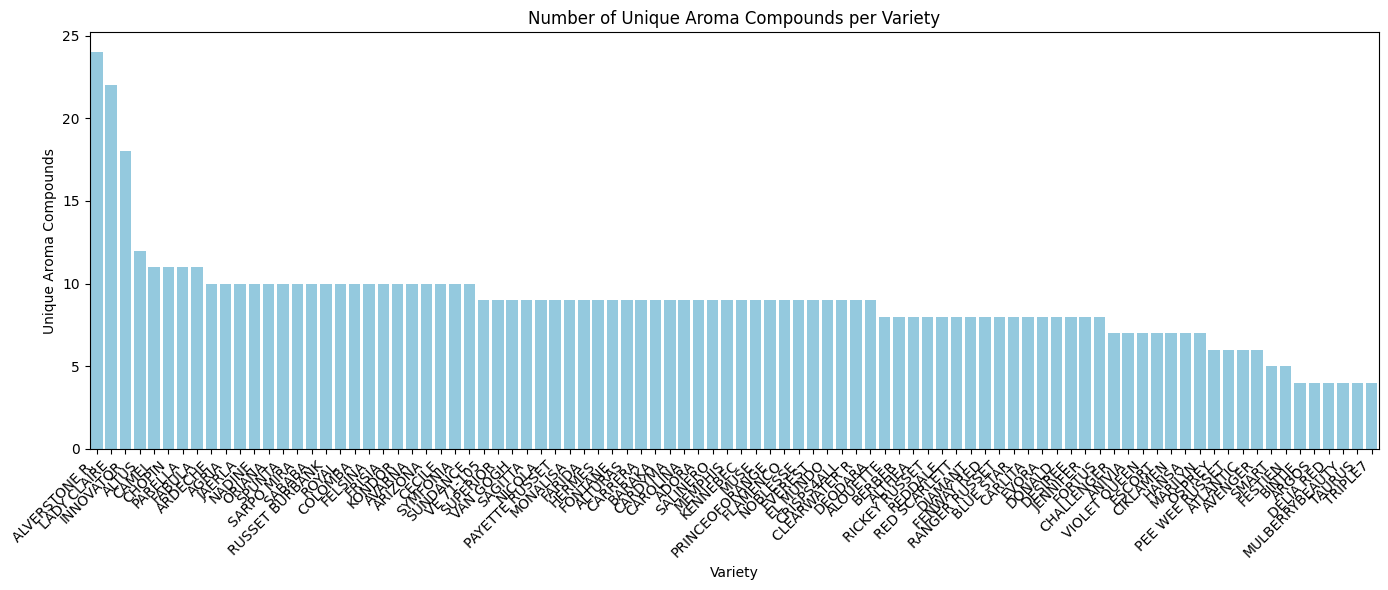

In [7]:
plt.figure(figsize=(14, 6))
sns.barplot(data=aroma_counts_by_variety, x='Variety', y='Aroma Count', color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Number of Unique Aroma Compounds per Variety")
plt.xlabel("Variety")
plt.ylabel("Unique Aroma Compounds")
plt.tight_layout()
plt.show()


The barplot shows the number of unique aroma compounds detected in each potato variety. Some varieties, like Alverstone Russet, Innovator, and Lady Claire, have a much higher number of aroma compounds (over 20), suggesting a more complex and diverse aroma profile. In contrast, some varieties such as Triple7 and Mulberry Beauty have fewer than 5 unique aroma compounds, indicating a simpler aroma composition

# Barplot: Top 20 most common aroma compounds

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9416\1015609044.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


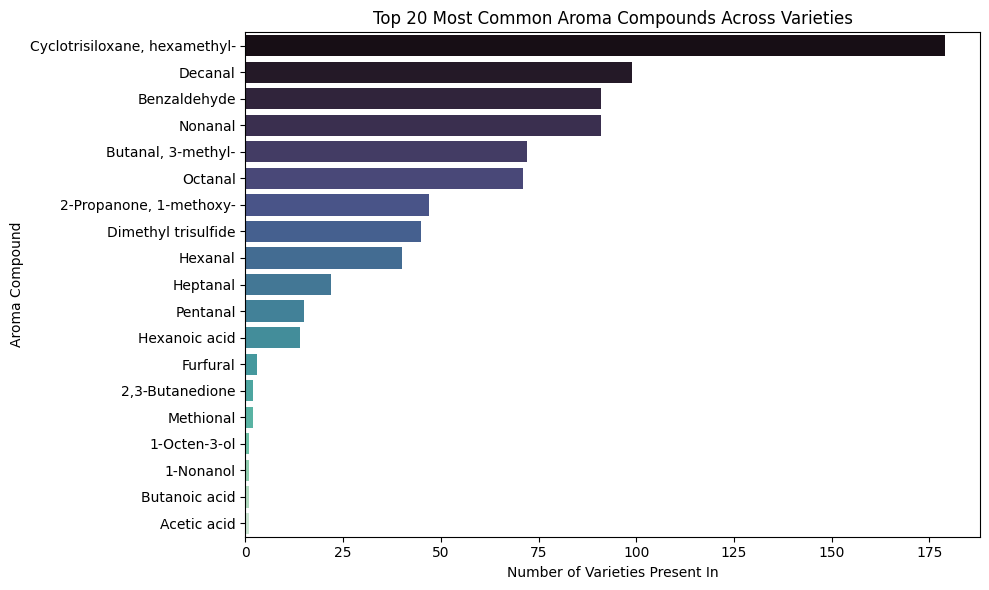

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=compound_frequency['Frequency'][:20], 
    y=compound_frequency['Aroma Compound'][:20],  
    palette='mako'
)
plt.title("Top 20 Most Common Aroma Compounds Across Varieties")
plt.xlabel("Number of Varieties Present In")
plt.ylabel("Aroma Compound")
plt.tight_layout()
plt.show()


The bar chart shows the most common aroma compounds found across all potato varieties. Compounds like Benzaldehyde, Cyclotrisiloxane (hexamethyl-), and Decanal, Nonanal were detected in almost every variety, making them the key contributors to the typical potato aroma. In contrast, compounds like Methional and Furfural appeared in only a few varieties, suggesting they are less common and may contribute to unique flavors in specific potatoes.

# Heatmap:  Visulization of variety vs Aroma Compound Presence

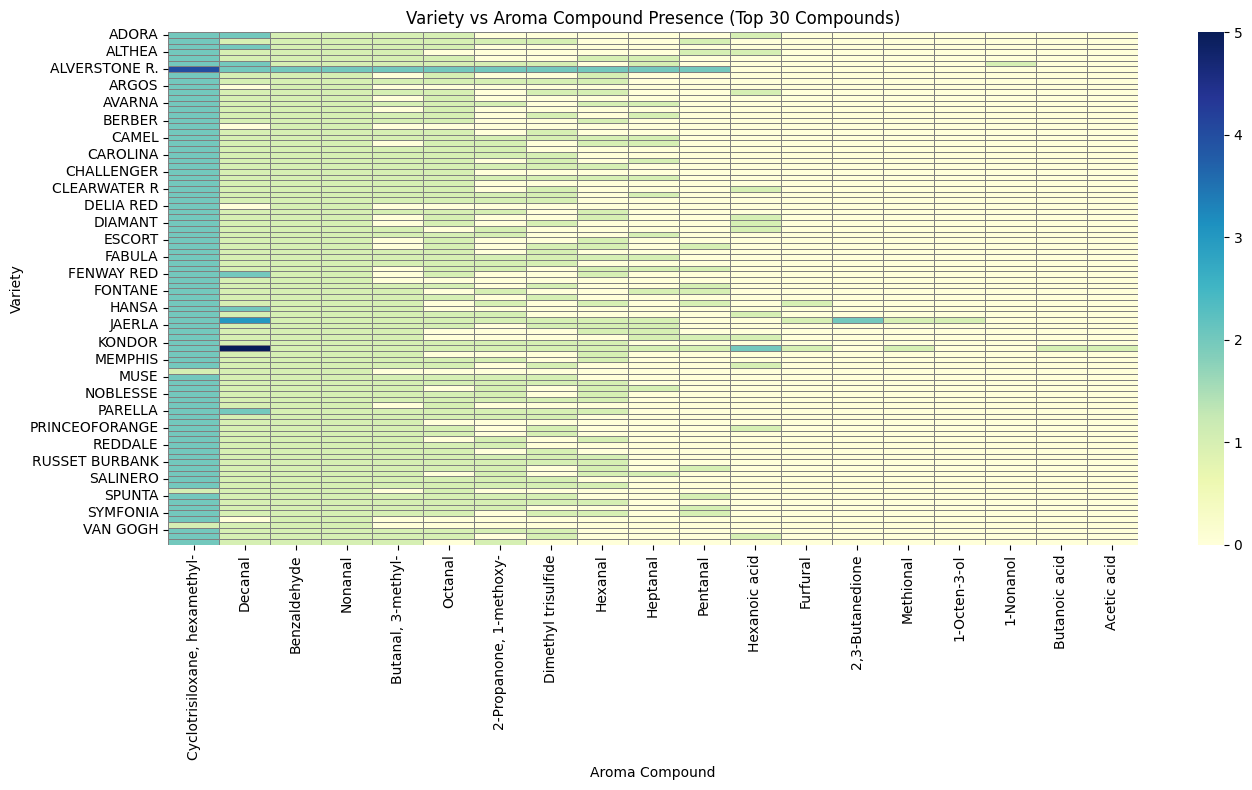

In [9]:
# Getting the top 30 compounds  to looking overally
top30_compounds = compound_frequency['Aroma Compound'][:30]
heatmap_data = variety_aroma_matrix[top30_compounds]

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5, linecolor='gray')
plt.title("Variety vs Aroma Compound Presence (Top 30 Compounds)")
plt.xlabel("Aroma Compound")
plt.ylabel("Variety")
plt.tight_layout()
plt.show()


Compounds like Cyclotrisiloxane, Decanal, and Benzaldehyde are common across many varieties, while others (like Methional and Furfural) are much rarer. as we described earlier by barplot

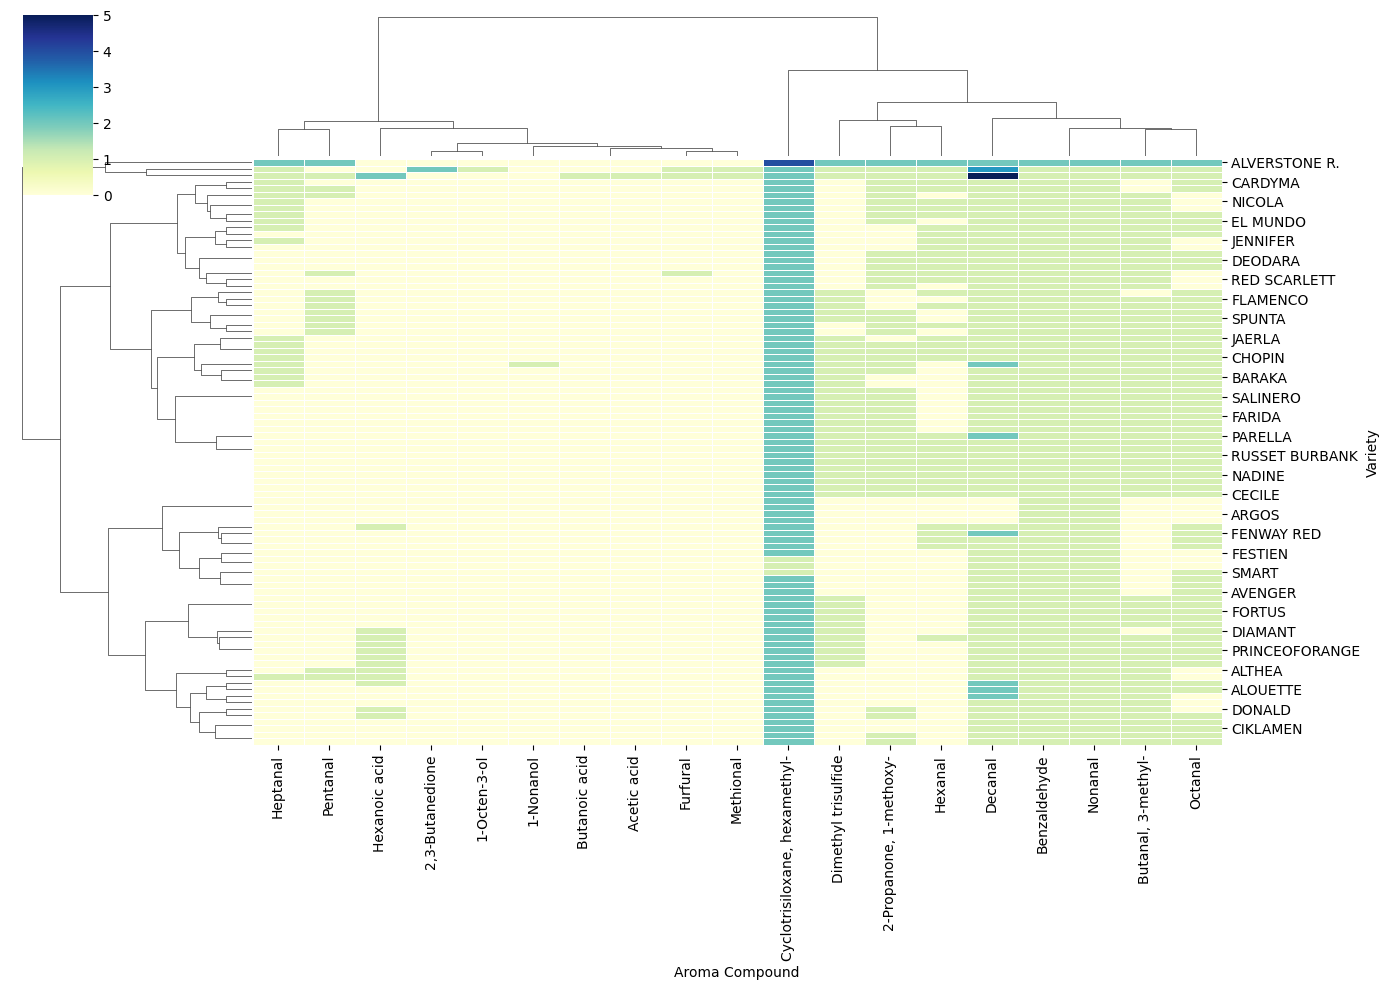

In [10]:
sns.clustermap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    figsize=(14, 10),
    method='ward',
    metric='euclidean'
)

# Compare INNOVATOR vs ALVERSTONE R   as an example to see which compounds are similar and which are diffrent

In [11]:

# Compare two varieties
variety1 = "INNOVATOR"
variety2 = "ALVERSTONE R."

compounds_variety1 = set(exploded.loc[exploded['Variety'] == variety1, 'Aroma Compound'])
compounds_variety2 = set(exploded.loc[exploded['Variety'] == variety2, 'Aroma Compound'])

# Find common and unique compounds
common_compounds = compounds_variety1.intersection(compounds_variety2)
unique_variety1 = compounds_variety1 - compounds_variety2
unique_variety2 = compounds_variety2 - compounds_variety1

# Create comparison table
comparison_df = pd.DataFrame({
    "Common Compounds": pd.Series(list(common_compounds)),
    f"Unique to {variety1}": pd.Series(list(unique_variety1)),
    f"Unique to {variety2}": pd.Series(list(unique_variety2))
})
print(comparison_df)

# Save to CSV
comparison_df.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Comparison_INNOVATOR_vs_ALVERSTONE.csv", index=False)
print("Comparison saved as 'Comparison_INNOVATOR_vs_ALVERSTONE.csv'")


                Common Compounds Unique to INNOVATOR Unique to ALVERSTONE R.
0            Dimethyl trisulfide        1-Octen-3-ol                Pentanal
1             Butanal, 3-methyl-     2,3-Butanedione                     NaN
2                   Benzaldehyde            Furfural                     NaN
3                        Hexanal           Methional                     NaN
4                        Nonanal                 NaN                     NaN
5                       Heptanal                 NaN                     NaN
6  Cyclotrisiloxane, hexamethyl-                 NaN                     NaN
7                        Decanal                 NaN                     NaN
8                        Octanal                 NaN                     NaN
9        2-Propanone, 1-methoxy-                 NaN                     NaN
Comparison saved as 'Comparison_INNOVATOR_vs_ALVERSTONE.csv'


# Jaccard Similarity Matrix for All Varieties

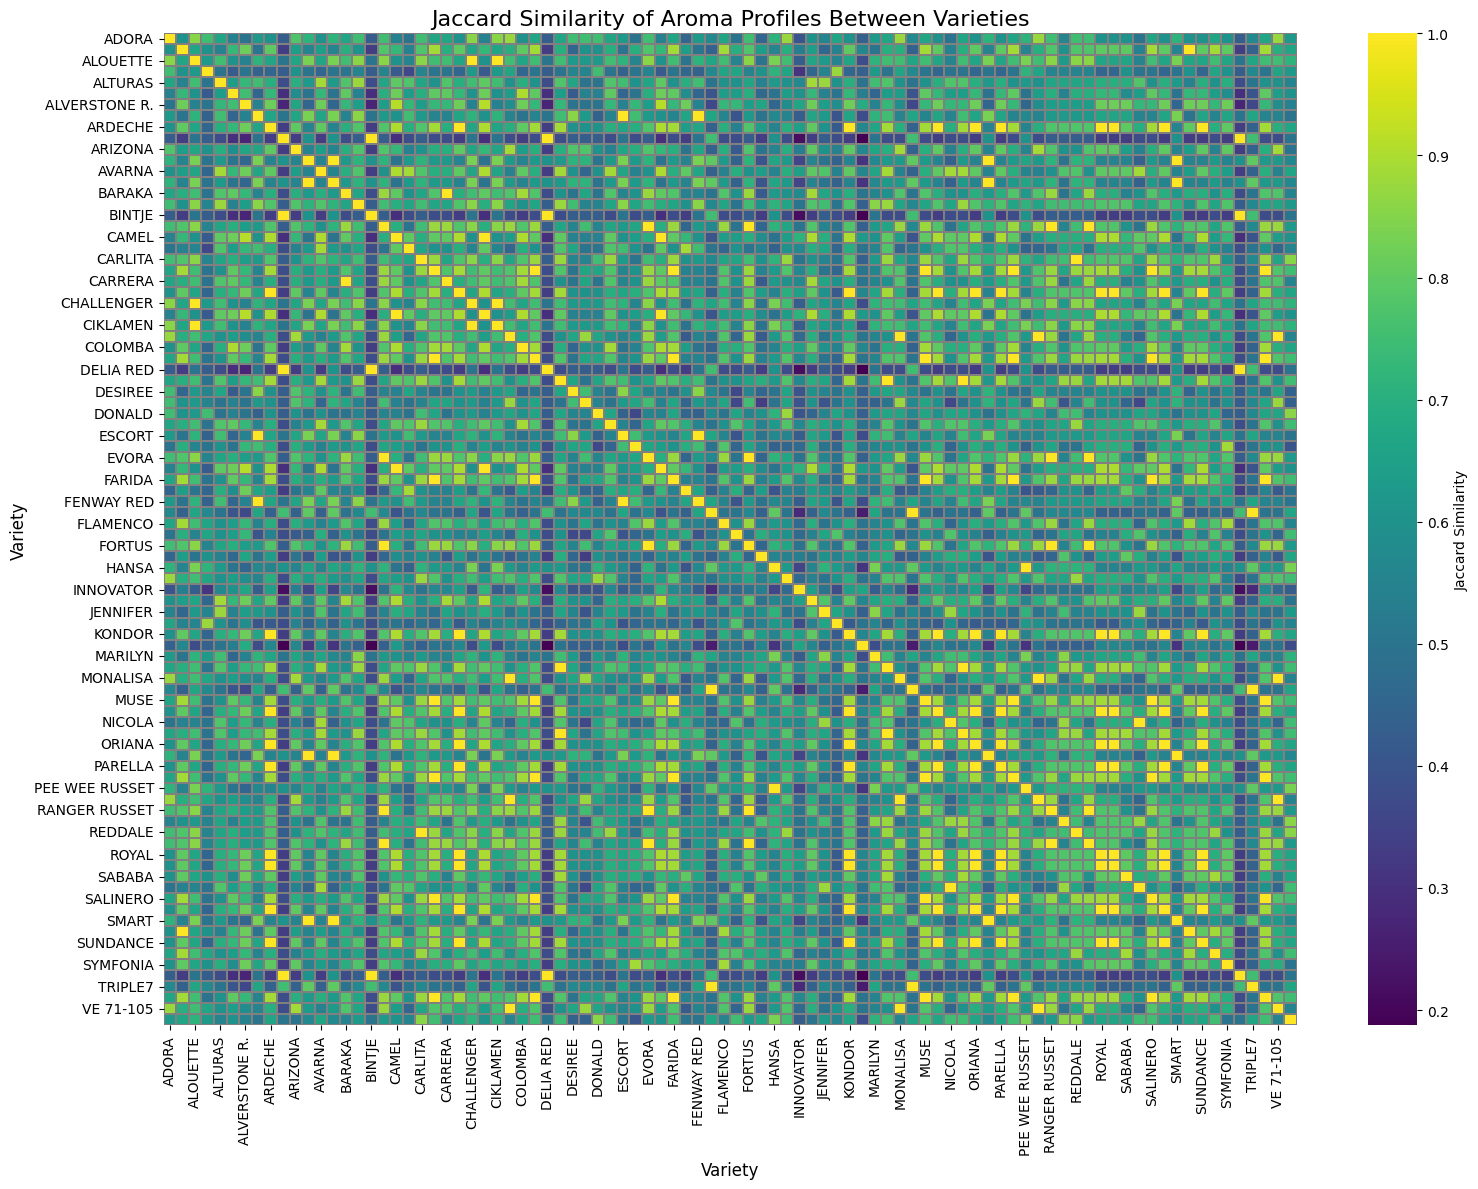

In [12]:

# Build a dictionary: variety 
variety_compounds = {
    v: set(exploded.loc[exploded['Variety'] == v, 'Aroma Compound'])
    for v in exploded['Variety'].unique()
}

# Compute Jaccard similarity for all pairs
varieties = list(variety_compounds.keys())
jaccard_matrix = pd.DataFrame(index=varieties, columns=varieties, dtype=float)

for v1 in varieties:
    for v2 in varieties:
        set1, set2 = variety_compounds[v1], variety_compounds[v2]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        jaccard_matrix.loc[v1, v2] = intersection / union if union > 0 else 0

# Display matrix
jaccard_matrix = jaccard_matrix.fillna(0)
jaccard_matrix

plt.figure(figsize=(16,12))
sns.heatmap(
    jaccard_matrix.astype(float),
    cmap="viridis",  # Better color range
    cbar_kws={'label': 'Jaccard Similarity'},
    linewidths=0.3,
    linecolor='gray'
)
plt.title("Jaccard Similarity of Aroma Profiles Between Varieties", fontsize=16)
plt.xlabel("Variety", fontsize=12)
plt.ylabel("Variety", fontsize=12)
plt.tight_layout()
plt.show()


The similarity in terms of the aroma compounds for varities can be seen by this plot

# Extract top 5 most similar and most different varieties


In [13]:
# Convert to long format
pairs = []
for i, v1 in enumerate(jaccard_matrix.index):
    for j, v2 in enumerate(jaccard_matrix.columns):
        if i < j:  # avoid duplicates and self-comparisons
            pairs.append((v1, v2, jaccard_matrix.loc[v1, v2]))

pairs_df = pd.DataFrame(pairs, columns=["Variety 1", "Variety 2", "Jaccard Similarity"])

# Top 5 most similar
top5_similar = pairs_df.sort_values(by="Jaccard Similarity", ascending=False).head(5)

# Top 5 most different
top5_different = pairs_df.sort_values(by="Jaccard Similarity", ascending=True).head(5)

# Combine results
top_pairs = pd.concat([
    top5_similar.assign(Type="Most Similar"),
    top5_different.assign(Type="Most Different")
])

top_pairs


,Variety 1,Variety 2,Jaccard Similarity,Type
2817,FARIDA,SALINERO,1.000000,Most Similar
1372,BINTJE,TAURUS,1.000000,Most Similar
1317,BINTJE,DELIA RED,1.000000,Most Similar
3906,RUSSET BURBANK,SUNDANCE,1.000000,Most Similar
3903,RUSSET BURBANK,SARPO MIRA,1.000000,Most Similar
1342,BINTJE,LADY CLAIRE,0.187500,Most Different
2259,DELIA RED,LADY CLAIRE,0.187500,Most Different
3439,LADY CLAIRE,TAURUS,0.187500,Most Different
810,ARGOS,LADY CLAIRE,0.187500,Most Different
2254,DELIA RED,INNOVATOR,0.214286,Most Different


#  Identify Flavor-Driving Compounds  
for  flavor identification in varities we need to use sensory panel but first we should clean this dataset to remove nan values and duplicates

# Using sensory panel

In [14]:
sensory = pd.read_excel(r"C:\Users\fatemehm\Downloads\Sensorial profiling SD 2005.xlsx")
print(sensory.columns)
sensory.head()

Index(['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour',
       'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness',
       'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes',
       'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma',
       'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
       'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour',
       'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour',
       'Sweet Flavour', 'Root/ Vegetable Flavour',
       'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel',
       'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh',
       'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin',
       'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste',
       'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47',
       'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK',
       'cluster 3 Sp, clu

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Cleaning of sensory dataset 

In [15]:

# Load sensory panel data
sensory = pd.read_excel(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx")
sensory['VARIETY'] = sensory['VARIETY'].astype(str).str.strip()
sensory.set_index('VARIETY', inplace=True)
sensory_traits = sensory.iloc[:, 3:47].apply(pd.to_numeric, errors='coerce')
sensory_traits = sensory_traits.drop(columns=[c for c in sensory_traits.columns if "Unnamed" in str(c)], errors='ignore')
sensory_traits = sensory_traits.groupby(sensory_traits.index).mean().fillna(sensory_traits.mean())

# PCA

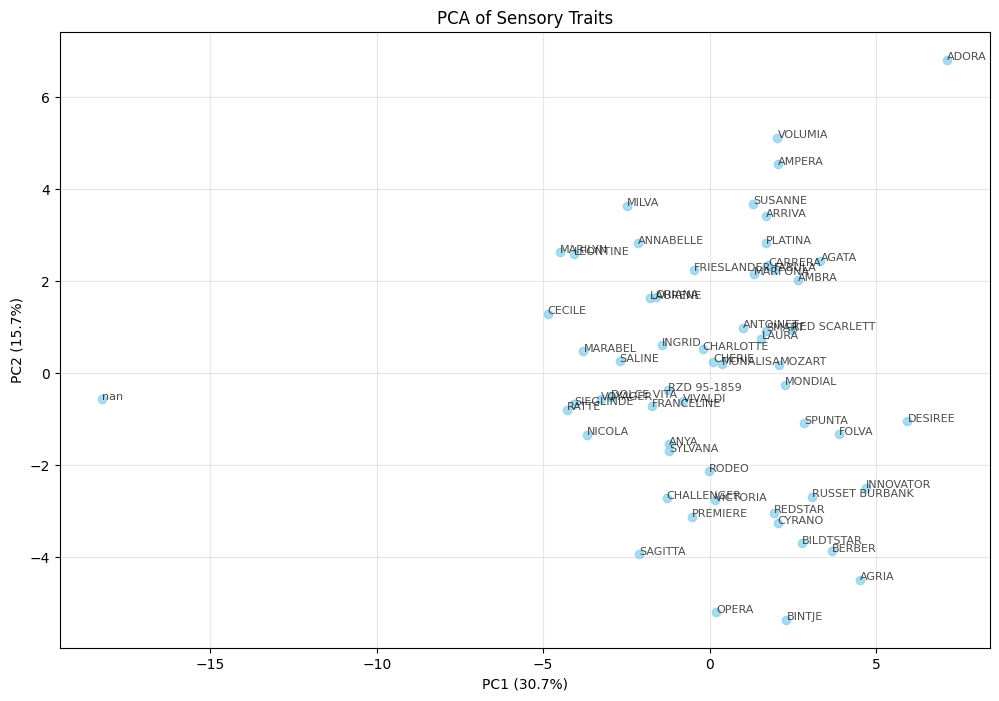

In [16]:

# Standardize the data
scaler = StandardScaler()
sensory_scaled = scaler.fit_transform(sensory_traits)

# Perform PCA
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(sensory_scaled)

# Plot PCA
plt.figure(figsize=(12, 8))
plt.scatter(pca_scores[:, 0], pca_scores[:, 1], alpha=0.7, color='skyblue')
for i, variety in enumerate(sensory_traits.index):
    plt.text(pca_scores[i, 0], pca_scores[i, 1], variety, fontsize=8, alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Sensory Traits")
plt.grid(alpha=0.3)
plt.show()


## Using plsr to find the flavor of variaties based on sensory panel

In [17]:

#Align datasets 
common_varieties = sorted(set(variety_aroma_matrix.index).intersection(sensory_traits.index))
X = variety_aroma_matrix.loc[common_varieties]
Y = sensory_traits.loc[common_varieties]

#  Standardize
X_scaled = StandardScaler().fit_transform(X)
Y_scaled = StandardScaler().fit_transform(Y)

# PLSR 
pls = PLSRegression(n_components=2)
pls.fit(X_scaled, Y_scaled)

# Get top compounds driving flavor 
compound_importance = pd.DataFrame(pls.x_loadings_, index=X.columns, columns=['PLS1', 'PLS2'])
compound_importance['Total_Importance'] = compound_importance.abs().sum(axis=1)
top_flavor_compounds = compound_importance.sort_values('Total_Importance', ascending=False).head(20)

# Save results
top_flavor_compounds.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Top_Flavor_Driving_Compounds.csv")
print("Top flavor-driving compounds saved to 'Top_Flavor_Driving_Compounds.csv'")
top_flavor_compounds

Top flavor-driving compounds saved to 'Top_Flavor_Driving_Compounds.csv'


,PLS1,PLS2,Total_Importance
Aroma Compound,,,
1-Octen-3-ol,0.448733,-0.327013,0.775745
"2,3-Butanedione",0.448733,-0.327013,0.775745
Methional,0.448733,-0.327013,0.775745
Furfural,0.448733,-0.327013,0.775745
Decanal,0.465953,-0.195812,0.661765
Hexanoic acid,0.209720,0.347826,0.557546
Octanal,0.356626,0.197468,0.554094
Hexanal,-0.143529,-0.322091,0.465620
"2-Propanone, 1-methoxy-",-0.056120,-0.374344,0.430464


The main flavor‑defining compounds for these potatoes are Methional, Furfural, Hexanal, Dimethyl trisulfide, Butanal (3‑methyl‑),Cyclotrisiloxane and Pentanal. and although Benzaldehyde,, hexamethyl-Nonanal interfered in potato aromas but they do not have a role as flavor

# To assess the importance of each flavor compound for differentiating the potato varieties, we loaded them into PLS components.

Varieties + Compounds + Sensory Attributes

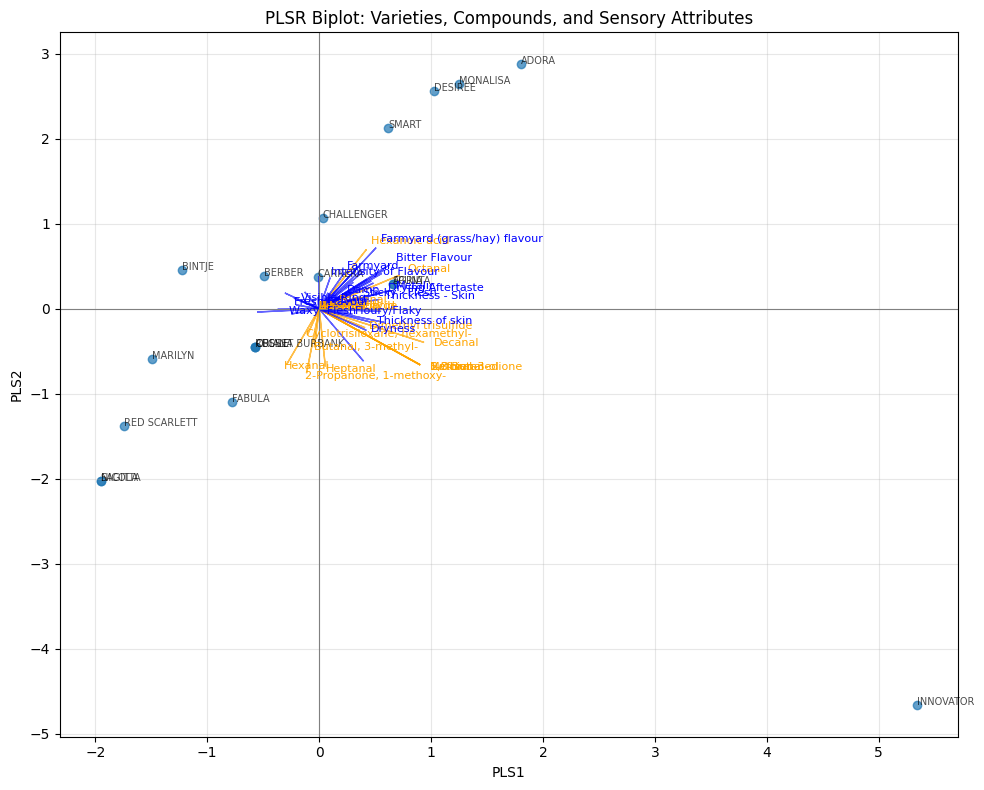

In [18]:
# Project data onto PLS components
X_scores = pls.x_scores_
Y_scores = pls.y_scores_
compounds_loadings = pls.x_loadings_
sensory_loadings = pls.y_loadings_

plt.figure(figsize=(10, 8))
# Plot varieties 
plt.scatter(X_scores[:, 0], X_scores[:, 1], alpha=0.7, label="Varieties")
for i, variety in enumerate(common_varieties):
    plt.text(X_scores[i, 0], X_scores[i, 1], variety, fontsize=7, alpha=0.7)

# Plot aroma compounds (loadings)
for i, compound in enumerate(X.columns):
    plt.arrow(0, 0, compounds_loadings[i, 0]*2, compounds_loadings[i, 1]*2,
              color='orange', alpha=0.7)
    plt.text(compounds_loadings[i, 0]*2.2, compounds_loadings[i, 1]*2.2, compound,
             color='orange', fontsize=8)
# Plot sensory traits
for i, trait in enumerate(Y.columns):
    plt.arrow(0, 0, sensory_loadings[i, 0]*2, sensory_loadings[i, 1]*2,
              color='blue', alpha=0.6)
    if i % 3 == 0: 
        plt.text(sensory_loadings[i, 0]*2.2, sensory_loadings[i, 1]*2.2, trait,
                 color='blue', fontsize=8)
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel("PLS1")
plt.ylabel("PLS2")
plt.title("PLSR Biplot: Varieties, Compounds, and Sensory Attributes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Varieties positioned closer to certain aroma compounds or traits are likely to have those characteristics. For example, Innovator stands out with a unique flavor profile, while varieties like Adora and Monalisa are linked with stronger sensory traits (farmyard or bitter notes). The clustering of many varieties near the center suggests they share more balanced, less distinctive flavor profiles.

# Heatmap (Varieties × Top Flavor Compounds)

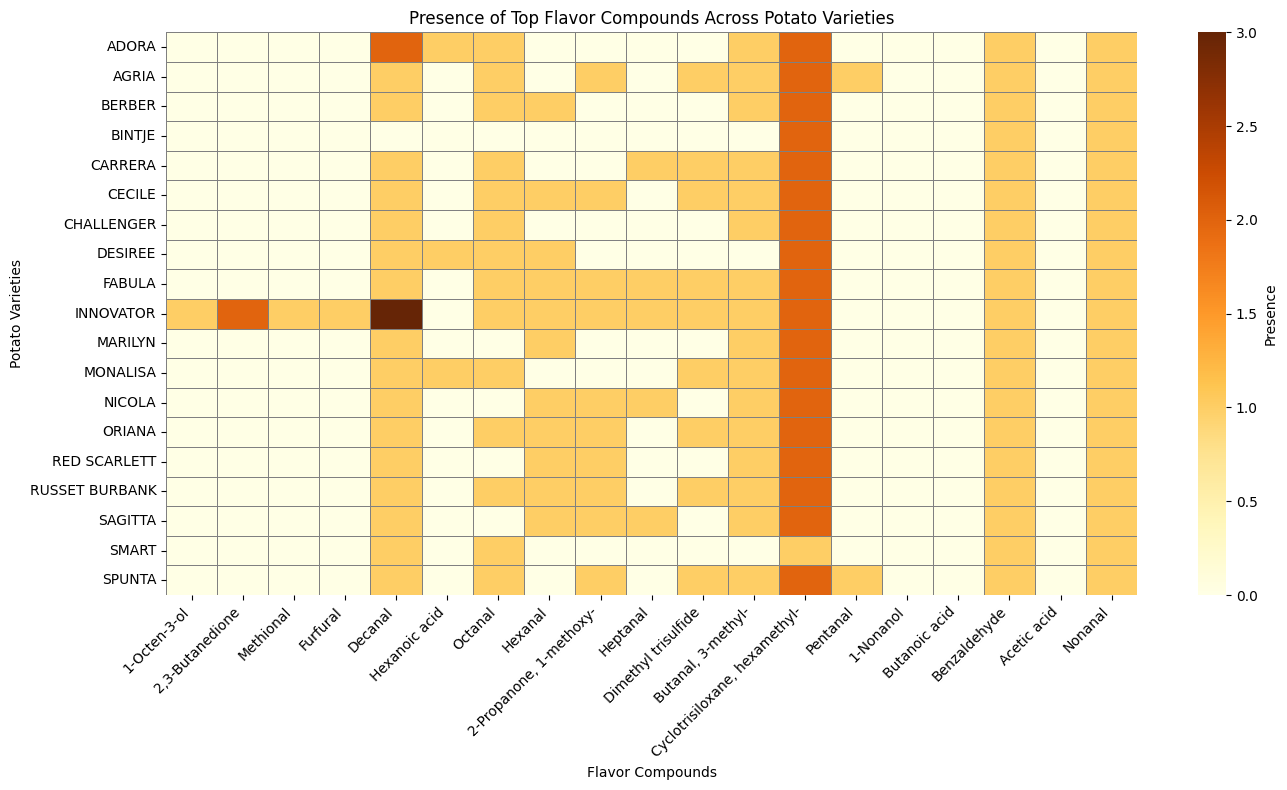

In [24]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlOrBr",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Presence'}
)
plt.title("Presence of Top Flavor Compounds Across Potato Varieties")
plt.xlabel("Flavor Compounds")
plt.ylabel("Potato Varieties")

# Force proper tick labels
plt.xticks(ticks=np.arange(len(top_compounds)) + 0.5, labels=top_compounds, rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


This graph explains why different potato varieties taste different. Some are naturally sweeter and more “cooked‑potato‑like,” while others are grassy, malty, or savory

Our sensory panel covers only some varieties, but we want flavor insight for all  so we should use only the varieties with both GC–MS compounds + sensory panel scores to train the plsr model and Predict flavor for the rest(the varities that we do not have sensory information for that)

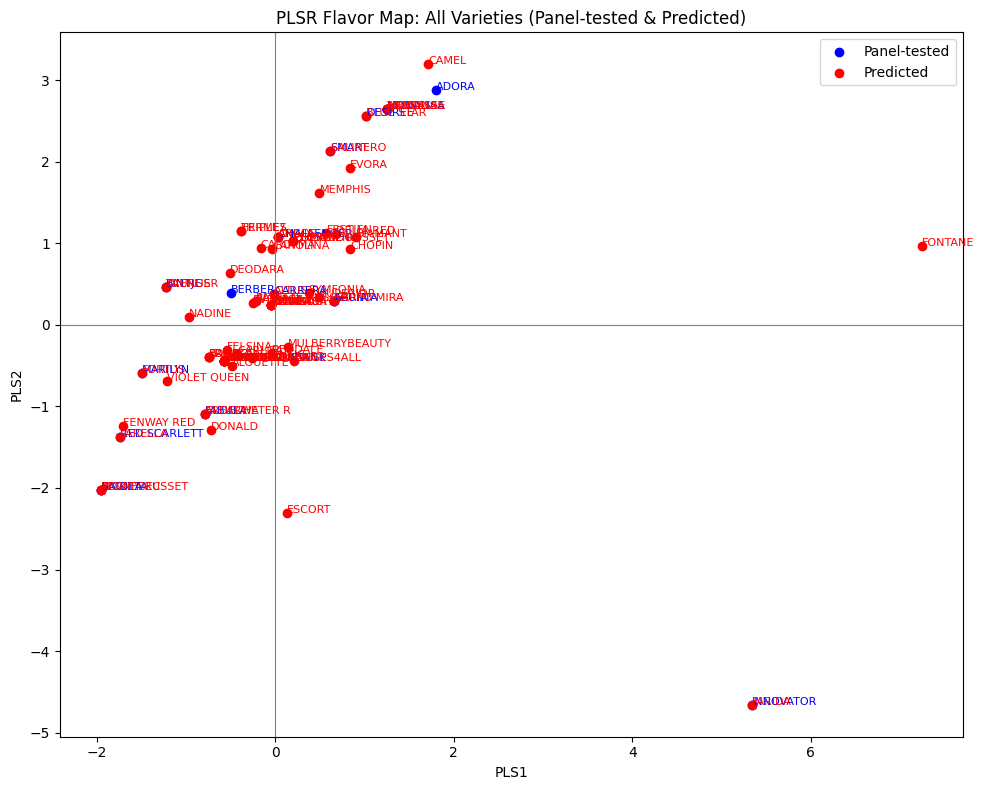

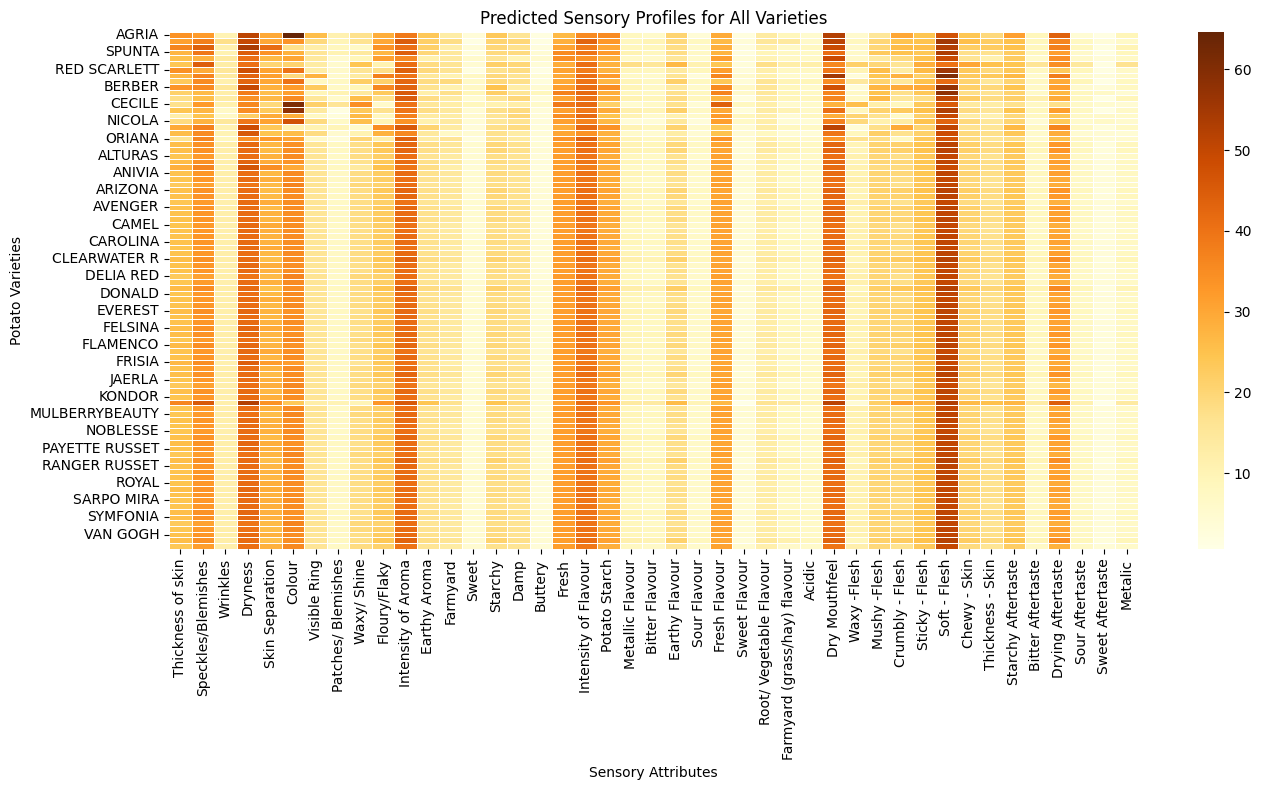

C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Predicted sensory profiles saved as 'Predicted_Sensory_Profiles.csv'


In [20]:
X_full = variety_aroma_matrix.copy()
Y_full = sensory_traits.copy()

# Split into varieties with and without sensory data
known_varieties = list(set(X_full.index).intersection(Y_full.index))
unknown_varieties = [v for v in X_full.index if v not in Y_full.index]
X_known = X_full.loc[known_varieties]
Y_known = Y_full.loc[known_varieties]
X_unknown = X_full.loc[unknown_varieties]

#Standardize
scaler_X = StandardScaler().fit(X_known)
X_known_scaled = scaler_X.transform(X_known)
X_unknown_scaled = scaler_X.transform(X_unknown)

scaler_Y = StandardScaler().fit(Y_known)
Y_known_scaled = scaler_Y.transform(Y_known)


# Train PLSR on known varieties
pls = PLSRegression(n_components=2)
pls.fit(X_known_scaled, Y_known_scaled)


#Predict sensory for unknown varieties
Y_pred_scaled = pls.predict(X_unknown_scaled)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)
Y_pred_df = pd.DataFrame(Y_pred, index=unknown_varieties, columns=Y_known.columns)

# Merge real + predicted sensory scores
all_sensory = pd.concat([Y_known, Y_pred_df])

# Project all varieties into PLS space
X_all_scaled = scaler_X.transform(X_full)
X_scores_all = pls.transform(X_all_scaled)  # PLS scores for all varieties

# Visualization: PLSR biplot
plt.figure(figsize=(10, 8))
# Plot known (panel-tested)
plt.scatter(pls.x_scores_[:, 0], pls.x_scores_[:, 1], color='blue', label="Panel-tested")
for i, name in enumerate(known_varieties):
    plt.text(pls.x_scores_[i, 0], pls.x_scores_[i, 1], name, fontsize=8, color='blue')
# Plot unknown (predicted)
plt.scatter(X_scores_all[len(known_varieties):, 0], X_scores_all[len(known_varieties):, 1], color='red', label="Predicted")
for i, name in enumerate(unknown_varieties):
    plt.text(X_scores_all[len(known_varieties)+i, 0], X_scores_all[len(known_varieties)+i, 1], name, fontsize=8, color='red')

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel("PLS1")
plt.ylabel("PLS2")
plt.title("PLSR Flavor Map: All Varieties (Panel-tested & Predicted)")
plt.legend()
plt.tight_layout()
plt.show()

#Heatmap of predicted sensory attributes
plt.figure(figsize=(14, 8))
sns.heatmap(all_sensory, cmap="YlOrBr", linewidths=0.5)
plt.title("Predicted Sensory Profiles for All Varieties")
plt.xlabel("Sensory Attributes")
plt.ylabel("Potato Varieties")
plt.tight_layout()
plt.show()

# Save predicted sensory data
all_sensory.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Predicted_Sensory_Profiles.csv")
print(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Predicted sensory profiles saved as 'Predicted_Sensory_Profiles.csv'")

Varieties near each other likely share similar flavor profiles.
for example, Innovator & Fontane are positioned far from the center it means they have strong, unique flavor characteristics (sweet/cooked potato-like).
Clusters near the center (like Russet types) indicate more balanced or milder flavors.

Also teh heatmap shows which flavor exists in each varities

We successfully used the relationship between aroma compounds and sensory data to predict the flavor profiles of all varieties. This means even varieties
that weren’t tasted by the panel can now be classified by their predicted flavor characteristics (sweet, earthy, buttery, etc.).

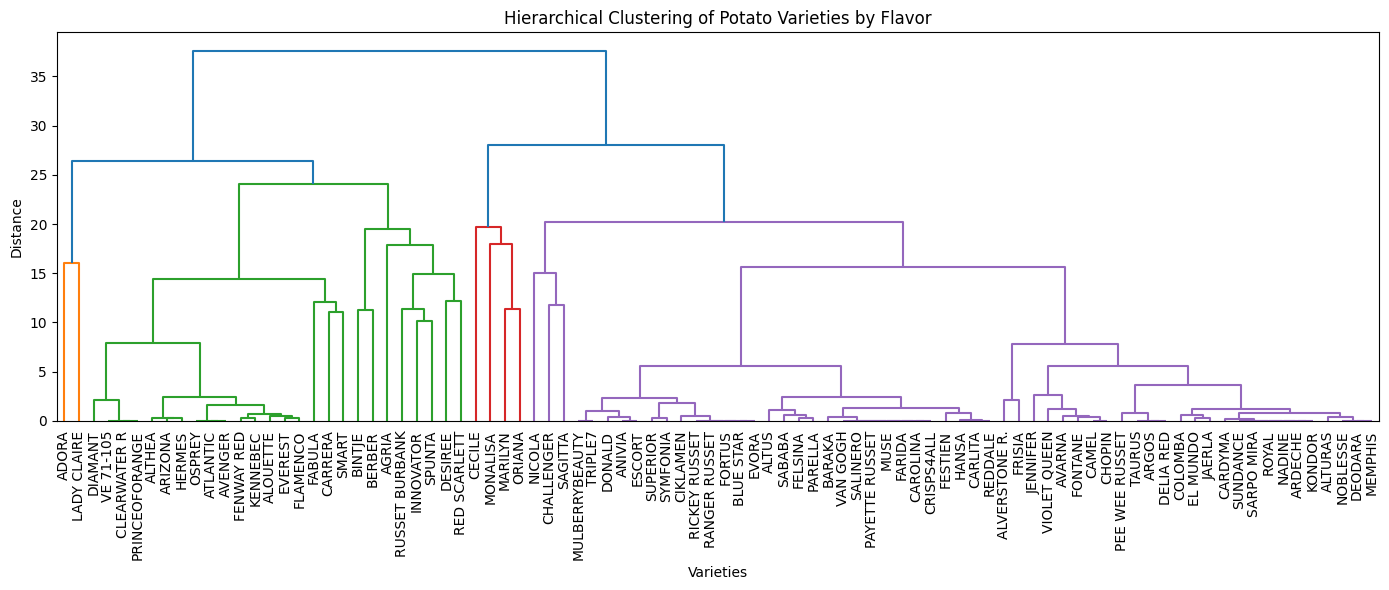

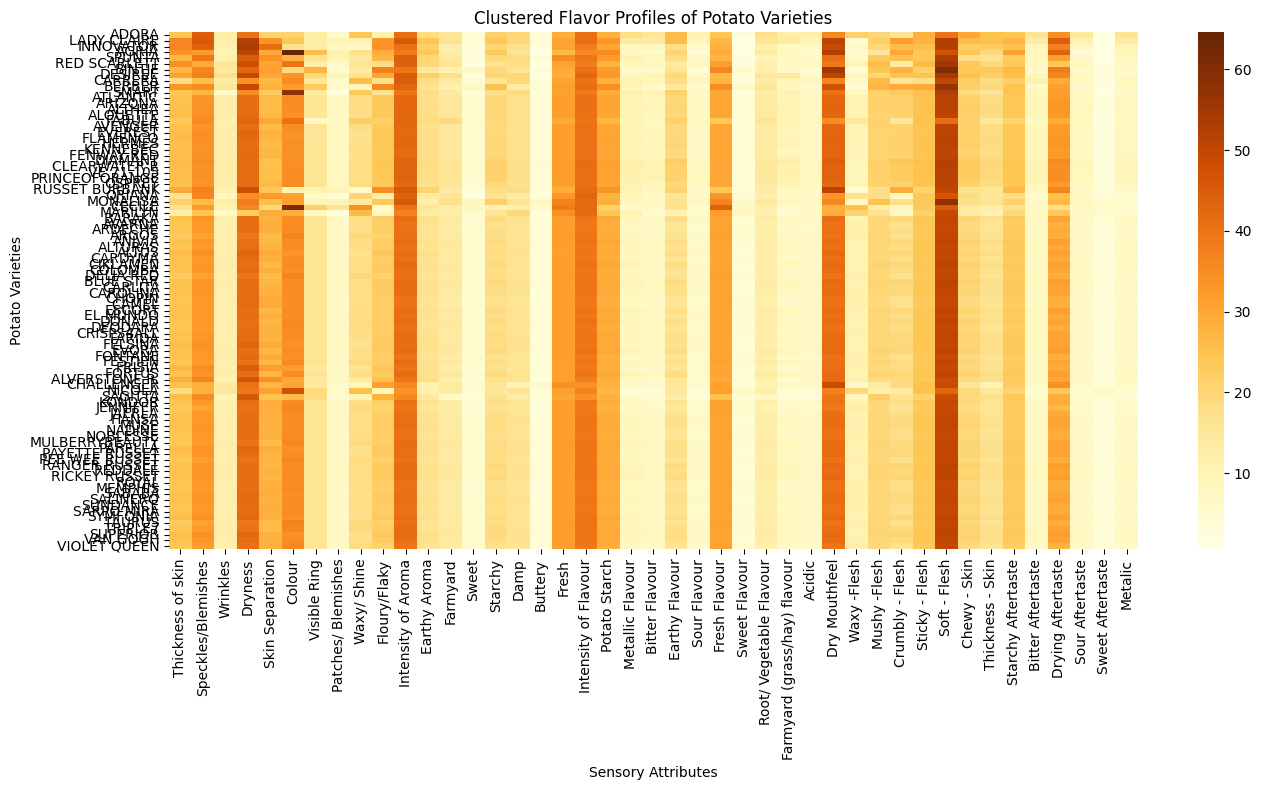

,Cluster
ADORA,1
LADY CLAIRE,1
INNOVATOR,2
AGRIA,2
SPUNTA,2
...,...
TAURUS,4
TRIPLE7,4
SUPERIOR,4
VAN GOGH,4


In [21]:

# Standardize data
scaler = StandardScaler()
sensory_scaled = scaler.fit_transform(all_sensory)

# Hierarchical clustering
linkage_matrix = linkage(sensory_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, labels=all_sensory.index, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of Potato Varieties by Flavor")
plt.xlabel("Varieties")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Choose number of clusters here i used 4 cluster
num_clusters = 4
clusters = fcluster(linkage_matrix, num_clusters, criterion='maxclust')
all_sensory['Cluster'] = clusters

# Plot clustered heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(all_sensory.drop(columns=['Cluster']).iloc[np.argsort(clusters)], 
            cmap="YlOrBr", yticklabels=all_sensory.index[np.argsort(clusters)])
plt.title("Clustered Flavor Profiles of Potato Varieties")
plt.xlabel("Sensory Attributes")
plt.ylabel("Potato Varieties")
plt.tight_layout()
plt.show()

# Show each variety’s cluster
cluster_groups = all_sensory[['Cluster']].sort_values('Cluster')
cluster_groups


in the dendogram
Group 1 (left): Varieties like Fenway Red, Escort, Ranger Russet, and Sarpo Mira taste milder and more balanced.
Group 2 (right): Varieties like Innovator, Russet Burbank, and Lady Claire have stronger, more distinctive flavors (like sweet, buttery, or cooked-potato notes).
Special case: Innovator stands out on its own, showing a very unique flavor profile.

in the heatmap, By looking at the clustering, we can see which varieties share similar flavor profiles and which ones stand out as unique. In simple terms, it’s a visual way to group potatoes based on how they taste and feel when eaten.

# Show the distribution of each sensory attribute across all varieties.

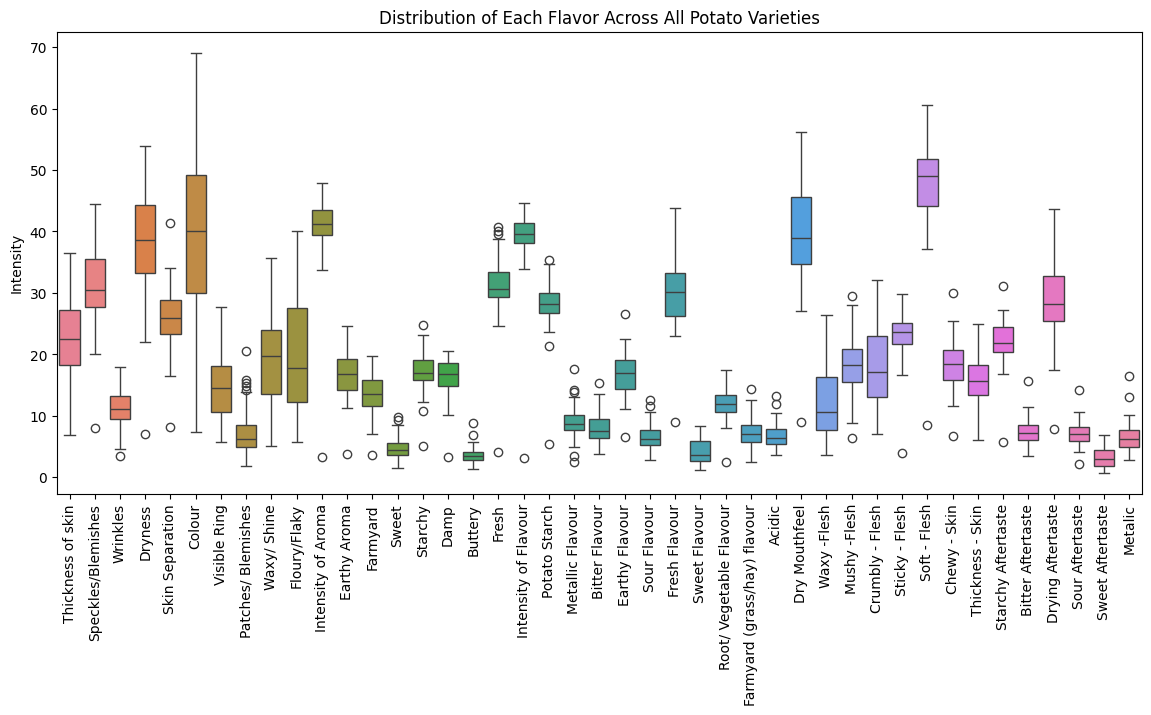

In [22]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=sensory_traits)  
plt.xticks(rotation=90)
plt.title("Distribution of Each Flavor Across All Potato Varieties")
plt.ylabel("Intensity")
plt.show()

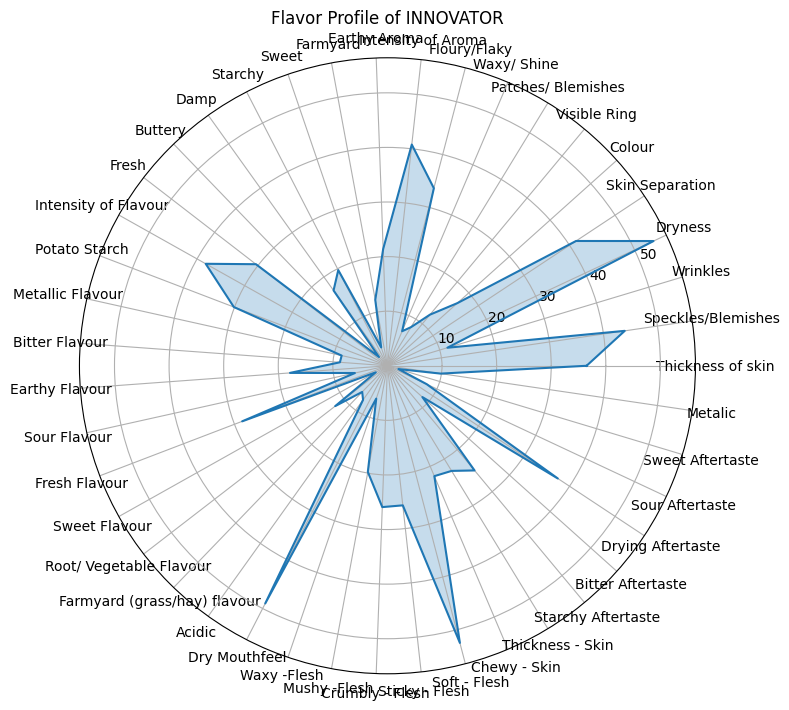

In [23]:


def radar_chart(data, variety_name):
    labels = data.columns
    values = data.loc[variety_name].values
    num_vars = len(labels)
    
    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]
    
    plt.figure(figsize=(8,8))
    plt.polar(angles, values)
    plt.fill(angles, values, alpha=0.25)
    plt.xticks(angles[:-1], labels, rotation=90)
    plt.title(f"Flavor Profile of {variety_name}")
    plt.show()

radar_chart(sensory_traits, "INNOVATOR")


This radar chart shows the flavor profile of Innovator potatoes. It’s clear that Innovator is very dry and starchy, with a floury/flaky texture and some waxy flesh. It has little sweetness or metallic taste and only mild buttery or fresh notes. In short, it’s a classic dry, starchy potato — great for mashing or baking.